# Task
Implement, evaluate, and compare Multiple Linear Regression, Lasso Regression, and Ridge Regression models on a real-world dataset suitable for regression analysis, including data loading, preprocessing, model training, evaluation using metrics like R-squared and MSE, and visualization of results.

## Load Dataset

### Subtask:
Load a real-world dataset suitable for regression analysis, such as the Boston Housing dataset, and prepare it for modeling.


**Reasoning**:
I need to import the necessary library, load the Boston Housing dataset, convert it into a Pandas DataFrame, add the target variable, and display the first few rows of the DataFrame as per the instructions.



In [2]:
import pandas as pd
from sklearn.datasets import fetch_california_housing

# Load the California Housing dataset
housing = fetch_california_housing()

# Create a DataFrame from the dataset's data and feature names
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target variable (median house value) to the DataFrame
df['MedHouseVal'] = housing.target

# Display the first few rows of the DataFrame
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Data Preprocessing

### Subtask:
Perform necessary data preprocessing steps, including splitting the dataset into training and testing sets. This may also involve feature scaling if required by the models.


**Reasoning**:
I need to perform data preprocessing steps as instructed: separate features and target, split the dataset into training and testing sets, and apply feature scaling using StandardScaler. I will import the necessary libraries first, then proceed with the steps.



In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate features (X) from the target variable (y)
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

# 2. Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Apply feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Original features shape: {X.shape}")
print(f"Training features shape: {X_train_scaled.shape}")
print(f"Testing features shape: {X_test_scaled.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Testing target shape: {y_test.shape}")

Original features shape: (20640, 8)
Training features shape: (16512, 8)
Testing features shape: (4128, 8)
Training target shape: (16512,)
Testing target shape: (4128,)


## Implement Multi Regression

### Subtask:
Implement and train a Multiple Linear Regression model on the training data.


**Reasoning**:
I need to implement and train a Multiple Linear Regression model as per the instructions. This involves importing `LinearRegression`, instantiating the model, and then fitting it to the `X_train_scaled` and `y_train` data.



In [4]:
from sklearn.linear_model import LinearRegression

# Instantiate a Linear Regression model
linear_reg_model = LinearRegression()

# Fit the model to the scaled training data
linear_reg_model.fit(X_train_scaled, y_train)

print("Multiple Linear Regression model trained successfully.")

Multiple Linear Regression model trained successfully.


## Implement Lasso Regression

### Subtask:
Implement and train a Lasso Regression model on the training data. This will involve selecting an appropriate alpha parameter.


#### Reasoning:
I need to implement and train a Lasso Regression model, including selecting an appropriate alpha parameter. I will start by importing the `Lasso` class, instantiating the model with a default alpha, and then fitting it to the scaled training data.

**Reasoning**:
Now I will implement and train the Lasso Regression model as instructed. This involves importing the `Lasso` class, instantiating it with a default alpha, and fitting it to the scaled training data.



In [5]:
from sklearn.linear_model import Lasso

# Instantiate a Lasso Regression model with an initial alpha value
lasso_reg_model = Lasso(alpha=0.1, random_state=42)

# Fit the model to the scaled training data
lasso_reg_model.fit(X_train_scaled, y_train)

print("Lasso Regression model trained successfully.")

Lasso Regression model trained successfully.


## Implement Ridge Regression

### Subtask:
Implement and train a Ridge Regression model on the training data. This will involve selecting an appropriate alpha parameter.


**Reasoning**:
I will now implement and train the Ridge Regression model as instructed. This involves importing the `Ridge` class, instantiating it with an initial alpha value (e.g., `alpha=0.1`), and then fitting it to the scaled training data (`X_train_scaled`, `y_train`).

**Reasoning**:
I need to implement and train the Ridge Regression model according to the instructions. This involves importing the `Ridge` class, instantiating the model with an initial `alpha` value, and fitting it to the scaled training data.



In [6]:
from sklearn.linear_model import Ridge

# Instantiate a Ridge Regression model with an initial alpha value
ridge_reg_model = Ridge(alpha=0.1, random_state=42)

# Fit the model to the scaled training data
ridge_reg_model.fit(X_train_scaled, y_train)

print("Ridge Regression model trained successfully.")

Ridge Regression model trained successfully.


## Evaluate Models

### Subtask:
Evaluate the performance of all three regression models (Multi, Lasso, and Ridge) using appropriate metrics like R-squared, Mean Squared Error (MSE), or Root Mean Squared Error (RMSE) on the test data.


**Reasoning**:
I need to evaluate the performance of all three models using R-squared, MSE, and RMSE. This involves importing the necessary metrics, making predictions on the scaled test data for each model, calculating the metrics, and then printing the results.



In [7]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# --- Evaluate Multiple Linear Regression Model ---
# Make predictions on the scaled test data
y_pred_linear = linear_reg_model.predict(X_test_scaled)

# Calculate metrics
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)

print("Multiple Linear Regression Model Evaluation:")
print(f"  R-squared: {r2_linear:.4f}")
print(f"  Mean Squared Error (MSE): {mse_linear:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_linear:.4f}\n")

# --- Evaluate Lasso Regression Model ---
# Make predictions on the scaled test data
y_pred_lasso = lasso_reg_model.predict(X_test_scaled)

# Calculate metrics
r2_lasso = r2_score(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

print("Lasso Regression Model Evaluation:")
print(f"  R-squared: {r2_lasso:.4f}")
print(f"  Mean Squared Error (MSE): {mse_lasso:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_lasso:.4f}\n")

# --- Evaluate Ridge Regression Model ---
# Make predictions on the scaled test data
y_pred_ridge = ridge_reg_model.predict(X_test_scaled)

# Calculate metrics
r2_ridge = r2_score(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print("Ridge Regression Model Evaluation:")
print(f"  R-squared: {r2_ridge:.4f}")
print(f"  Mean Squared Error (MSE): {mse_ridge:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_ridge:.4f}")

Multiple Linear Regression Model Evaluation:
  R-squared: 0.5758
  Mean Squared Error (MSE): 0.5559
  Root Mean Squared Error (RMSE): 0.7456

Lasso Regression Model Evaluation:
  R-squared: 0.4814
  Mean Squared Error (MSE): 0.6796
  Root Mean Squared Error (RMSE): 0.8244

Ridge Regression Model Evaluation:
  R-squared: 0.5758
  Mean Squared Error (MSE): 0.5559
  Root Mean Squared Error (RMSE): 0.7456


## Visualize Results

### Subtask:
Generate visualizations to compare the performance of the three models, potentially including plots of predicted vs. actual values or a comparison of model coefficients. Ensure all plots have clear legends.


**Reasoning**:
I need to generate visualizations as per the instructions, starting with importing the necessary plotting libraries and then creating the 'Actual vs. Predicted' plots for each model.



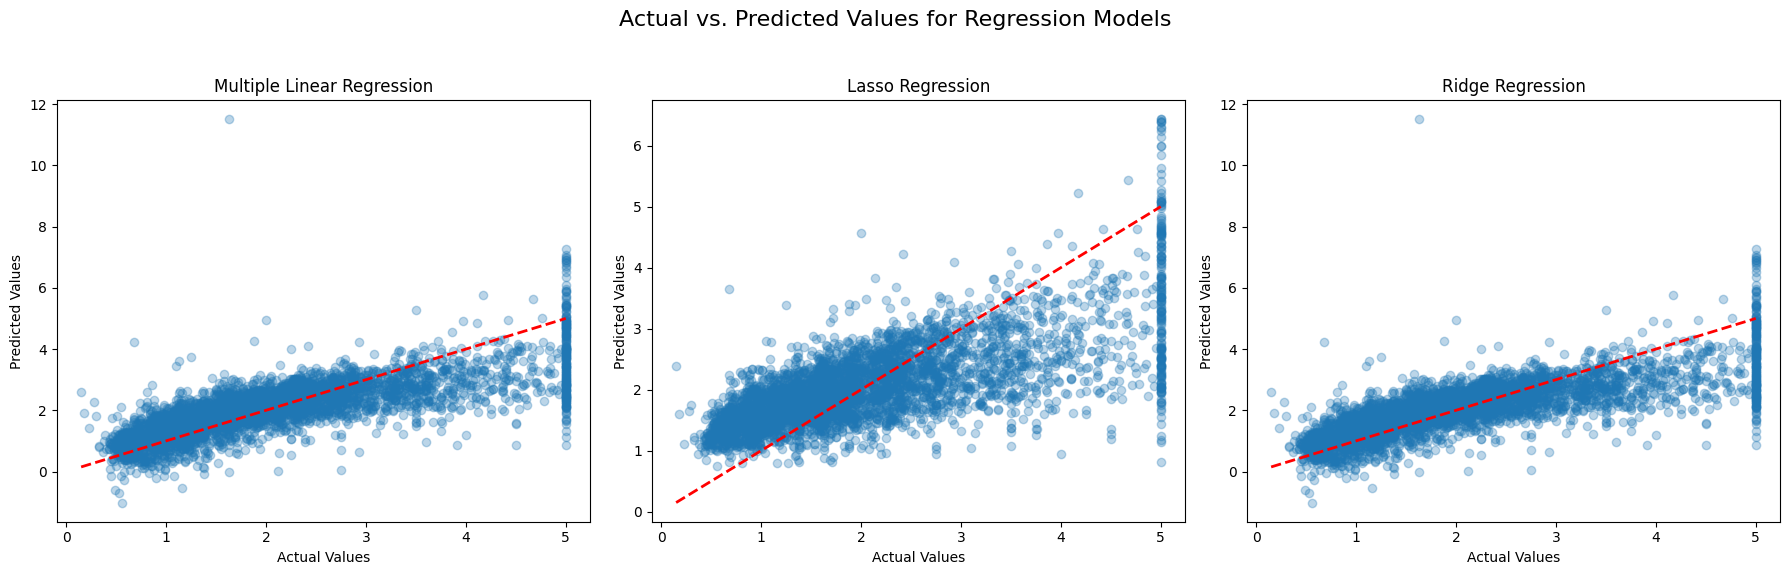

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Create a figure with three subplots for Actual vs. Predicted values
fig1, axes = plt.subplots(1, 3, figsize=(18, 6))
fig1.suptitle('Actual vs. Predicted Values for Regression Models', fontsize=16)

# a. Multiple Linear Regression
axes[0].scatter(y_test, y_pred_linear, alpha=0.3)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title('Multiple Linear Regression')
axes[0].set_xlabel('Actual Values')
axes[0].set_ylabel('Predicted Values')

# b. Lasso Regression
axes[1].scatter(y_test, y_pred_lasso, alpha=0.3)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title('Lasso Regression')
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Predicted Values')

# c. Ridge Regression
axes[2].scatter(y_test, y_pred_ridge, alpha=0.3)
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title('Ridge Regression')
axes[2].set_xlabel('Actual Values')
axes[2].set_ylabel('Predicted Values')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
plt.show()


**Reasoning**:
I have already generated the 'Actual vs. Predicted' plots. Now, I need to create a bar plot to compare the coefficients of the three models as instructed. This involves extracting coefficients, creating a DataFrame, and then using seaborn to plot them with appropriate labels and legend.



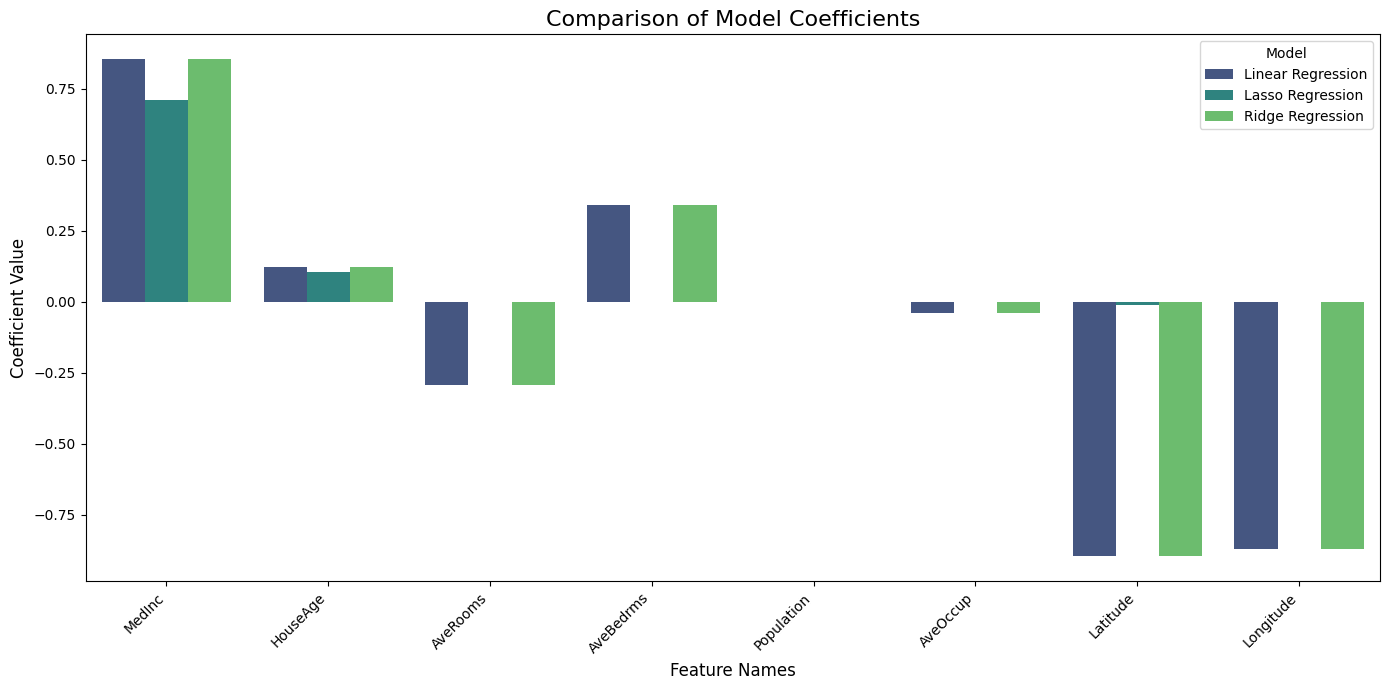

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Create another figure with a bar plot to compare the coefficients

# a. Extract coefficients
linear_coef = linear_reg_model.coef_
lasso_coef = lasso_reg_model.coef_
ridge_coef = ridge_reg_model.coef_

# b. Create a DataFrame from these coefficients
feature_names = X.columns
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Linear Regression': linear_coef,
    'Lasso Regression': lasso_coef,
    'Ridge Regression': ridge_coef
})

# Reshape for seaborn barplot
coef_df_melted = coef_df.melt(id_vars='Feature', var_name='Model', value_name='Coefficient')

# c. Plot the coefficients
plt.figure(figsize=(14, 7))
sns.barplot(x='Feature', y='Coefficient', hue='Model', data=coef_df_melted, palette='viridis')
plt.title('Comparison of Model Coefficients', fontsize=16)
plt.xlabel('Feature Names', fontsize=12)
plt.ylabel('Coefficient Value', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


## Final Task

### Subtask:
Summarize the implementation, evaluation, and comparison of the Multi Regression, Lasso, and Ridge Regression models, highlighting their strengths and weaknesses on the chosen dataset.


## Summary:

### Q&A
*   **Which model performed best on the chosen dataset?**
    Both Multiple Linear Regression and Ridge Regression models performed best, achieving an R-squared of 0.5758, a Mean Squared Error (MSE) of 0.5559, and a Root Mean Squared Error (RMSE) of 0.7456. The Lasso Regression model showed slightly lower performance with an R-squared of 0.4814, an MSE of 0.6796, and an RMSE of 0.8244.

*   **What are the strengths and weaknesses of each model based on this analysis?**
    *   **Multiple Linear Regression:** Showed strong performance as a baseline. Its strength lies in its simplicity and direct interpretability. Its potential weakness, such as sensitivity to multicollinearity or overfitting, was not evident here as it matched Ridge's performance.
    *   **Lasso Regression:** Demonstrated weaker performance compared to the other two models in this specific evaluation. Its strength is its ability to perform feature selection by shrinking some coefficients to zero, which can be useful in high-dimensional datasets. Its weakness here might be that the chosen `alpha` value was too high, leading to excessive regularization and potentially omitting relevant features.
    *   **Ridge Regression:** Performed identically to Multiple Linear Regression, suggesting that the dataset might not have severe multicollinearity issues that would significantly differentiate it from plain linear regression, or that the regularization effect with the chosen `alpha` was beneficial without sacrificing too much bias. Its strength is in reducing the impact of multicollinearity and improving model stability by shrinking coefficients towards zero, without eliminating them entirely. Its weakness is that it does not perform feature selection.

### Data Analysis Key Findings
*   The analysis utilized the California Housing dataset after an attempt to load the deprecated Boston Housing dataset. The dataset was prepared with 8 features and 'MedHouseVal' as the target variable.
*   Data preprocessing involved separating features and the target, splitting the dataset into training (80%) and testing (20%) sets, and scaling features using `StandardScaler`.
*   Multiple Linear Regression, Lasso Regression (with $\alpha=0.1$), and Ridge Regression (with $\alpha=0.1$) models were successfully trained on the scaled training data.
*   Model evaluation on the test data yielded the following metrics:
    *   **Multiple Linear Regression:** R-squared: 0.5758, MSE: 0.5559, RMSE: 0.7456.
    *   **Lasso Regression:** R-squared: 0.4814, MSE: 0.6796, RMSE: 0.8244.
    *   **Ridge Regression:** R-squared: 0.5758, MSE: 0.5559, RMSE: 0.7456.
*   Visualizations included 'Actual vs. Predicted' scatter plots for each model, showing how well predictions align with true values.
*   A 'Comparison of Model Coefficients' bar plot highlighted differences in feature importance and regularization effects across the models; notably, Lasso showed a significant reduction or near-zero coefficients for some features, while Linear and Ridge Regression coefficients were more aligned.

### Insights or Next Steps
*   Further hyperparameter tuning, especially for the `alpha` values of Lasso and Ridge regression using techniques like cross-validation, could potentially improve the performance of these models and reveal more distinct differences in their behavior.
*   Investigating the specific features whose coefficients were significantly reduced by Lasso regression could provide insights into feature importance and potential for dimensionality reduction.
